In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import betainc

## 1. EDA

Посмотрим на данные, обработаем пропуски, дубли. Посмотрим на распределения признаков.

In [ ]:
data = pd.read_csv('data/data_ab.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


### 1.1 Пропуски, признаки, дубли

Есть временной признак, посмотрим на него

In [292]:
data.timestamp.dtype

<StringDtype(storage='python', na_value=nan)>

приведем тип к `datetime`

In [293]:
data['timestamp'] = pd.to_datetime(data['timestamp'])
data.timestamp.head()

0   2025-01-21 22:11:48.556739
1   2025-01-12 08:01:45.159739
2   2025-01-11 16:55:06.154213
3   2025-01-08 18:28:03.143765
4   2025-01-21 01:52:26.210827
Name: timestamp, dtype: datetime64[us]

Проверим данные на **пропуски** и **полные дубликаты**

In [294]:
data.isna().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [295]:
data.duplicated().sum()

np.int64(0)

Проверим возможные значения признаков `group`, `landing_page`, `converted` 

In [296]:
data.converted.value_counts()

converted
0    259241
1     35237
Name: count, dtype: int64

In [297]:
data.group.value_counts()

group
treatment    147276
control      147202
Name: count, dtype: int64

In [298]:
data.landing_page.value_counts()

landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

Заметим, что число распределения `group` и `landing_page` не совпадают. Рассмотрим подробнее.

In [299]:
grpops = data.groupby(by=["group", "landing_page"])
sums = grpops.agg({"user_id": "count", "converted": "mean"})
sums

user_id  converted
group     landing_page                    
control   new_page         1928   0.121369
          old_page       145274   0.120386
treatment new_page       145311   0.118807
          old_page         1965   0.127226

Посмотрим, уникальны ли пользователи

In [300]:
data.shape[0], data["user_id"].nunique()

(294478, 290584)

In [301]:
data.shape[0] - data["user_id"].nunique()

3894

Дубли возможны как:

пользователь сделал несколько посещений сайта, все разы видя
1)  **одинаковую** версию страницы 
2) **разные** версии страницы

In [302]:
vc = data["user_id"].value_counts()
doubled_users = vc[vc > 1].index

In [303]:
doubled_users_10 = doubled_users[:10]
data[data["user_id"].isin(doubled_users_10)].sort_values(by="user_id")

,user_id,timestamp,group,landing_page,converted
192,656468,2025-01-18 07:13:29.805052,treatment,new_page,1
110937,656468,2025-01-02 16:31:05.777407,treatment,old_page,0
252137,670052,2025-01-04 23:41:21.033734,treatment,old_page,1
269,670052,2025-01-07 10:39:01.099851,control,old_page,0
327,686623,2025-01-09 14:26:40.734775,treatment,old_page,0
248316,686623,2025-01-23 21:49:11.503132,treatment,new_page,0
246,704650,2025-01-04 19:10:52.655062,treatment,new_page,0
29105,704650,2025-01-02 20:55:59.535550,treatment,old_page,0
240,733976,2025-01-11 15:11:16.407599,control,new_page,0
284201,733976,2025-01-05 12:14:56.557333,treatment,new_page,0


Делаем вывод, что повторные посещения пользователей сайта могли быть **как на одну версию страницы**, так и **на разные**. Причем в поседнем случаем первая (по времени наблюдения) могла быть как `old_page`, так и `new_page`.

Также посмотрим сколько всего пользователей, которые дважды появлялись на сайте.

In [304]:
data.shape[0], doubled_users.shape, doubled_users.shape[0] / data.shape[0]

(294478, (3894,), 0.013223398691922657)

Классическое допущение A/B тестирвоания - независимость тестовой и контольной группы. Если пользователи бывают в обоих группах, то выборки получаются зависимы, и независимость распределений не выполняется. 

Бороться с этим можно двумя путями
1) оставить первое наблюдение за пользователем (тк второе посщение может зависеть от первого). 
2) удалить все значения пользователей, если они в числе тех, кто был в разных группах эксперемента.


Первый путь сохраняет больше данных для работы, но у такого подхода есть существенный минус: мы не знаем, почему система (сплитовалка пользователей или же сайт) допускала такую ошибку в разбиениях. 

Эта неизвестность не дает сделать вывод о том, почему такие наблюдения появились и **можем ли мы считать их корректными**. Ведь функуционал сайта мог работать некорректно и отображать истинное распределение.


Также заметим, что таких записей всего $1,32\%$, к тому же со среднее значение `converted` в таких группах примерно равно, и, скорее всего, не даст стат. значимой разницы, если ее учесть. Потому просто удалим те наблюдения, `user_id` которых встречался более 1 раза.

Однако важно проверить, не удалим ли мы таких пользователей, которые более одного раза корректно были отнесены и к одной группе (`control`/`treatment`), и к одной финальной странице сайта (`old_page`/`new_page`) 

In [305]:
def check_user_records(records):
    if all((records.group == "treatment") & (records.landing_page == "new_page")): return True
    if all((records.group == "control") & (records.landing_page == "old_page")): return True
    return False

np.sum(data[data.user_id.isin(doubled_users)].groupby("user_id").apply(check_user_records))

np.int64(1)

Такое значение одно. Сочтем его неважным.

Попробуем посмотреть на распределение выбросов во времени: может, дело в каком-то одном дне, когда система сломалась?

    timestamp  user_id
0  2025-01-02       81
1  2025-01-03      188
2  2025-01-04      172
3  2025-01-05      205
4  2025-01-06      163
    timestamp  user_id
0  2025-01-02       71
1  2025-01-03      179
2  2025-01-04      178
3  2025-01-05      166
4  2025-01-06      189


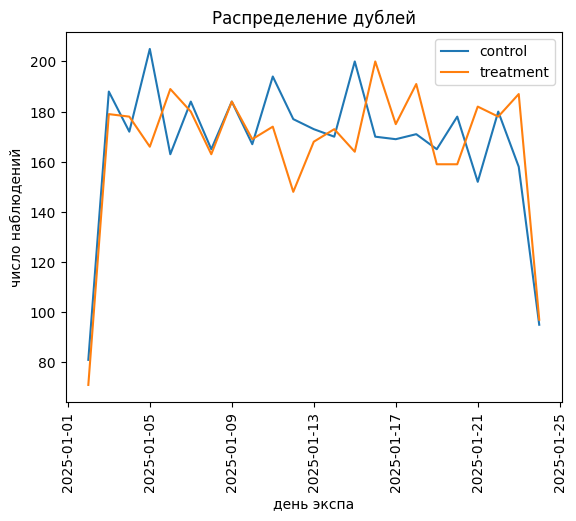

In [306]:
import matplotlib.pyplot as plt
df = data[data["user_id"].isin(doubled_users)]
data_time = df.copy()
data_time['timestamp'] = data_time['timestamp'].dt.date
data_time = data_time[data_time['group']=='control']
data_time = data_time.groupby('timestamp')['user_id'].nunique().reset_index()
print(data_time.head())
plt.plot(data_time['timestamp'],data_time[['user_id']], label = 'control')

data_time = df.copy()
data_time['timestamp'] = data_time['timestamp'].dt.date
data_time = data_time[data_time['group']=='treatment']
data_time = data_time.groupby('timestamp')['user_id'].nunique().reset_index()
print(data_time.head())
plt.plot(data_time['timestamp'],data_time[['user_id']],label = 'treatment')

plt.xlabel("день экспа")
plt.ylabel("число наблюдений")
plt.title("Распределение дублей")
plt.xticks(rotation=90)
plt.legend()

Интерпретируем это так: дубли приходились на все дни эксперемента, то есть не было какой-то временной технической ошибки.

In [307]:
prepared_data = data[~data.user_id.isin(doubled_users)]
prepared_data.shape, data.shape

((286690, 5), (294478, 5))

### 1.2 Распределения признаков

Сначала, посмотрим на продолжительность эксперемента и на число записей в каждый его день.

    timestamp  user_id
0  2025-01-02     2813
1  2025-01-03     6494
2  2025-01-04     6481
3  2025-01-05     6330
4  2025-01-06     6518
    timestamp  user_id
0  2025-01-02     2818
1  2025-01-03     6531
2  2025-01-04     6448
3  2025-01-05     6418
4  2025-01-06     6650


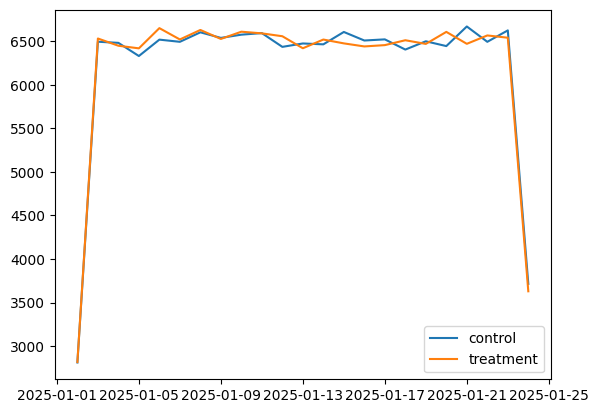

In [308]:
data_time = prepared_data.copy()
data_time['timestamp'] = data_time['timestamp'].dt.date
data_time = data_time[data_time['group']=='control']
data_time = data_time.groupby('timestamp')['user_id'].nunique().reset_index()
print(data_time.head())
plt.plot(data_time['timestamp'],data_time[['user_id']], label = 'control')

data_time = prepared_data.copy()
data_time['timestamp'] = data_time['timestamp'].dt.date
data_time = data_time[data_time['group']=='treatment']
data_time = data_time.groupby('timestamp')['user_id'].nunique().reset_index()
print(data_time.head())
plt.plot(data_time['timestamp'],data_time[['user_id']],label = 'treatment')
plt.legend()

Эксперемент начался **1го января** и закончился **25 января**. За это время значения приходили к нам примерно равномерно по дням (ни в выходные, ни в будни не было скачков)

Также заметим, что распределение на контроль/тест почти равно $50\%$

Посмотрим на пиковые часы нашего лендинга

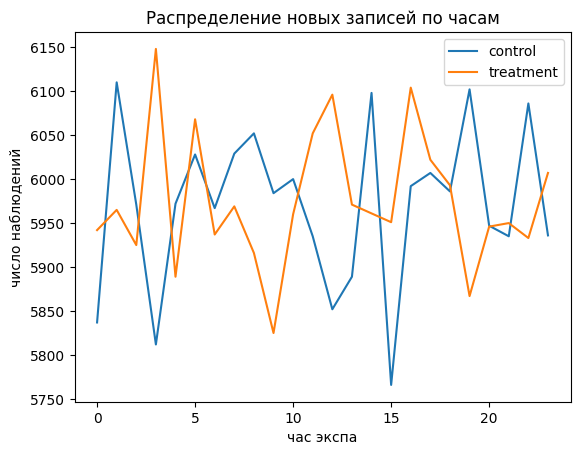

In [309]:
data_time = prepared_data.copy()
data_time['timestamp'] = data_time['timestamp'].dt.hour
data_time = data_time[data_time['group']=='control']
data_time = data_time.groupby('timestamp')['user_id'].nunique().reset_index()
plt.plot(data_time['timestamp'],data_time[['user_id']],label = 'control')

data_time = prepared_data.copy()
data_time['timestamp'] = data_time['timestamp'].dt.hour
data_time = data_time[data_time['group']=='treatment']
data_time = data_time.groupby('timestamp')['user_id'].nunique().reset_index()
plt.plot(data_time['timestamp'],data_time[['user_id']],label = 'treatment')

plt.xlabel("час экспа")
plt.ylabel("число наблюдений")
plt.title("Распределение новых записей по часам")
plt.legend()

Eсли посмотреть на ось Y, распределение от 5750 до 6150, то есть прыгаем всего на 350 юзеров в час максимум, а значит отличие на 5-6 процентов, что не страшно

## 2 A/B тестирование

### 2.1 Метрика

Конверисия, это, по сути, среднее. Это и будет метрикой, изменение которого будем пытаться поймать.

### 2.2 Гипотеза

В нашей задаче мы хотим узнать **есть ли изменения в конверсии** при использовании новой страницы.

Используем двусторонную гипотезу о равенстве средних.
$$H_0:\bar X_t -  \bar X_c = 0$$
$$H_1:\bar X_t -  \bar X_c\neq 0$$

Для этого будем использовать **t-test**

# TODO  


### 2.3 Оцениваем MDE задним числом

MDE (e) можно оценить после окончания эксперемента по ф-ле:

$$e > \sqrt{(z_{1-\alpha/2} + z_{1-\beta})^2\left(\dfrac{\hat\sigma_t^2}{n} + \dfrac{\hat\sigma_с^2}{m}\right)}$$

Мы можем найти $\hat\sigma_t^2, \hat\sigma_с^2, n, m$, однако нам незветсно $\alpha, \beta$.

Раз так, попробуем просто перебрать и исходя из нашей экспертной оценки определить минимально детектируемых эффект

In [310]:
alpha = [0.01, 0.05, 0.1]
beta = [0.1, 0.2, 0.3]

p1 = data[(data['group'] == 'control')]['converted'].sum()/data[(data['group'] == 'control')]['converted'].count()
p2 = data[(data['group'] == 'treatment')]['converted'].sum()/data[(data['group'] == 'treatment')]['converted'].count()
n1 = data[(data['group'] == 'control')]['converted'].count()
n2 = data[(data['group'] == 'treatment')]['converted'].count()
se1 = (p1*(1-p1)/n1)**0.5
se2 = (p2*(1-p2)/n2)**0.5

In [311]:
from scipy.stats import norm

results = []

for a in alpha:
    for b in beta:
        e = ((norm.ppf(1 - a/2) + norm.ppf(1 - b))**2 * (se1**2 + se2**2))**0.5
        
        results.append({
            'error_I': int(a * 100),
            'error_II': int(b * 100),
            'power': int((1 - b) * 100),
            'mde_%': round(e * 100, 3)
        })

df_results = pd.DataFrame(results)
df_results

,error_I,error_II,power,mde_%
0,1,10,90,0.461
1,1,20,80,0.409
2,1,30,70,0.371
3,5,10,90,0.388
4,5,20,80,0.335
5,5,30,70,0.297
6,10,10,90,0.350
7,10,20,80,0.297
8,10,30,70,0.259


Видим, что в завсисмоти от $\alpha, \beta$ mde колеблется от `0.461%` до `0.259%`.

Остановимся на классических значениях $\alpha = 0.05, \beta=0.2$ и mde = `0.335%`, что довольно точная оценка



### 2.4 A/A тесты

Перед началом самого теста важно удостовериться, что данные в рамках одной группы на самом деле неразличимы. Для этого будем использовать A/A тесты и бутстрапом оценивать доперительный интервал для ошибки 1го рода, если значение $\alpha = 0.05$ находится в нем, значит, критерий валиден и группа однородна.

Также задумаемся над **агрегацией пользователей**, то есть какими-то усреднениями значений пользователей. Классический вариант - агрегация по юзерам - нам недоступна (все пользователи уникальны). Однако можем также рассмотреть 

1) не использовать агрегацию
2) агрегацию батчами
3) агрегацию по дням (но тк их всего 24 и приозйдет слишком сильное сглаживание, сделаем агрегация по часам)

Проведем все 3 эксперемента и оценим, чей ДИ лучше подходит под тест.

Следующий важный момент, говоря про бутстрап и p-value. При равенстве нулевой гипотезы p-value распределно **равномерно**.

Для проверки распределения на равномерность, можем использовать
1) QQ-plot, сравнивающий теоретические квантили с наблюдаемыми
2) Эмпирическая ф-ия распределения
3) Критерий Колмогорова-Смирнова

напишем функции для этого это мат чуда

In [ ]:
def ci(
    pvalue_vector: np.array,
    alpha=0.05
) -> tuple[float, float, float]:
    n = len(pvalue_vector)
    n_critical = np.sum(pvalue_vector <= alpha)
    p = n_critical / n
    var = p * (1 - p) / n
    scale = stats.norm.ppf(1-alpha/2)
    eps = np.sqrt(var) * scale
    left_bound = p - eps
    right_bound = p + eps
    return p, left_bound, right_bound


def ks_uniformity_check(
    pvalue_vector: np.ndarray,
):
    n = len(pvalue_vector)
    sorted_pvals = np.sort(pvalue_vector)
    theoretical_cdf = sorted_pvals

    d_plus  = np.max(np.arange(1, n + 1) / n - theoretical_cdf)
    d_minus = np.max(theoretical_cdf - np.arange(0, n) / n)

    print(d_plus.shape)

    D_n = max(d_plus, d_minus)
    lam = np.sqrt(n) * D_n

    p_value = 2 * sum(
        ((-1) ** (k - 1)) * np.exp(-2 * k**2 * lam**2)
        for k in range(1, 100) 
    )
    p_value = np.clip(p_value, 0, 1)

    # ks_stat, ks_pval = stats.kstest(pvalue_vector, 'uniform', args=(0, 1))
    # assert np.isclose(D_n, ks_stat, atol=1e-6) \
    #        and np.isclose(ks_pval, p_value, atol=1e-2), f"something went wrong {D_n, ks_stat, p_value, ks_pval}"

    return D_n, p_value


def plot_comparison_with_uniform(
    pvalue_vector: list,
    title: str,
    aplha=0.05,
    color='orange'
):
    pvalue_vector = np.array(pvalue_vector)
    n = len(pvalue_vector)
    p, left_boundary, right_boundary = ci(pvalue_vector, aplha)
    print(f"Ошибка I рода: {round(p, 4)},\nCI для oшибки I рода: [{round(left_boundary, 4)}, {round(right_boundary, 4)}]")

    _, ax1 = plt.subplots(1, 3, figsize=(17, 5))

    # Гистограмма P-value
    ax1[0].hist(pvalue_vector, bins=30, edgecolor='black', alpha=0.6, color=color)
    ax1[0].set_title(
        f'распределение P-value'
    )
    ax1[0].set_xlabel('P-value')
    ax1[0].set_ylabel('Частота')

    # QQ-график
    stats.probplot(pvalue_vector, dist=stats.uniform, plot=ax1[1])
    ax1[1].get_lines()[1].set_linestyle('--')
    ax1[1].set_title(f'{title} (QQ-график)')

    # Эмпирическая функция распределения
    sorted_pvalue_vector = sorted(pvalue_vector)
    ordinal_positions = np.arange(1, n+1) / n
    x_uniform = np.linspace(0, 1, 100)
    cdf_uniform = x_uniform

    ax1[2].step(sorted_pvalue_vector, ordinal_positions, where='post', label='Эмпирическая ФР', color=color)
    ax1[2].plot(x_uniform, cdf_uniform, 'k--', label='Теоретическая CDF $U[0,1]$')
    ax1[2].set_title('Эмпирическая и теоретическая ФР')
    ax1[2].set_xlabel('p-value')
    ax1[2].set_ylabel('dist(p-value)')

    # Тест Колмогорова-Смирнова
    ks_statistic, ks_p_value = ks_uniformity_check(pvalue_vector)
    print(f'Статистика Колмогорова-Смирнова: {round(ks_statistic, 4)}, pvalue для сравнения ЭФР с равномерным: {round(ks_p_value, 4)}')
    if ks_p_value < 0.05:
        print("Гипотеза H0 отвергается: выборка НЕ из равномерного U(0,1)")
    else:
        print("Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)")

    ax1[2].text(
        0.05, 0.9,
        f"KS: stat={ks_statistic:.3f}\np={ks_p_value:.3f}",
        fontsize=10,
        verticalalignment='top',
        bbox={"boxstyle": "round", "facecolor": "w"}
    )
    plt.tight_layout()
    plt.show()


def t_test(x_num, y_num): # rename that
    n1, n2 = len(x_num), len(y_num)
    mean1, mean2 = np.mean(x_num), np.mean(y_num)
    var1, var2 = np.var(x_num), np.var(y_num)
    
    se = np.sqrt(var1/n1 + var2/n2)
    z_stat = (mean1 - mean2) / se
    return z_stat, 2 * (1 - stats.norm.cdf(abs(z_stat)))


def student_ttest(test_event: np.ndarray, control_event: np.ndarray) -> tuple[float, float]:
    n1, n2 = len(test_event), len(control_event)
    df = n1 + n2 - 2
    mean1, mean2 = np.mean(test_event), np.mean(control_event)

    var1 = np.sum((test_event - mean1)**2) / (n1 - 1)
    var2 = np.sum((control_event - mean2)**2) / (n2 - 1)
    var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)

    t_stat = (mean1 - mean2) / np.sqrt(var * (1/n1 + 1/n2))
    p_value = betainc(df / 2, 0.5, df / (df + t_stat**2))

    # ts, tpval = stats.ttest_ind(test_event, control_event)
    # assert np.isclose(t_stat, ts) and np.isclose(tpval, p_value), f"{t_stat, ts, tpval, p_value}"
    return t_stat, p_value

In [313]:
n = 1000

vec_control = data.loc[(data["group"] == "control"), "converted"]
vec_treatment = data.loc[(data["group"] == "treatment"), "converted"]

In [ ]:
pval_raw = []
for i in range(n):
    indices = np.random.binomial(1, 0.5, len(vec_control)).astype(bool)
    control_group = vec_control.loc[indices]
    treatment_group = vec_control.loc[~indices]
    _, p_val_c = student_ttest(control_group, treatment_group)
    pval_raw.append(p_val_c)

In [315]:
n_batches = 2000
pval_batches = []
batches = np.array_split(vec_control, n_batches)
avg_on_batches = pd.Series([batch.mean() for batch in batches])

for i in range(n):
    indices = np.random.binomial(1, 0.5, len(avg_on_batches)).astype(bool)
    control_batches = avg_on_batches.loc[indices]
    treatment_batches = avg_on_batches.loc[~indices]
    _, pvalue = student_ttest(control_batches, treatment_batches)
    pval_batches.append(pvalue)

In [316]:
agg_by_hour = \
    df[df["group"] == "control"]\
    .groupby(pd.Grouper(key='timestamp', freq='1h'))\
    .agg({'converted': 'mean'})\
    .converted
pvalue_hour = []

for i in range(n):
    indices = np.random.binomial(1, 0.5, len(agg_by_hour)).astype(bool)
    control_houres = agg_by_hour.loc[indices]
    treatment_houres =agg_by_hour.loc[~indices]
    _, pvalue = student_ttest(control_houres, treatment_houres)
    pvalue_hour.append(pvalue)

Ошибка I рода: 0.048,
CI для oшибки I рода: [0.0348, 0.0612]
()
Статистика Колмогорова-Смирнова: 0.0265, pvalue для сравнения ЭФР с равномерным: 0.4847
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


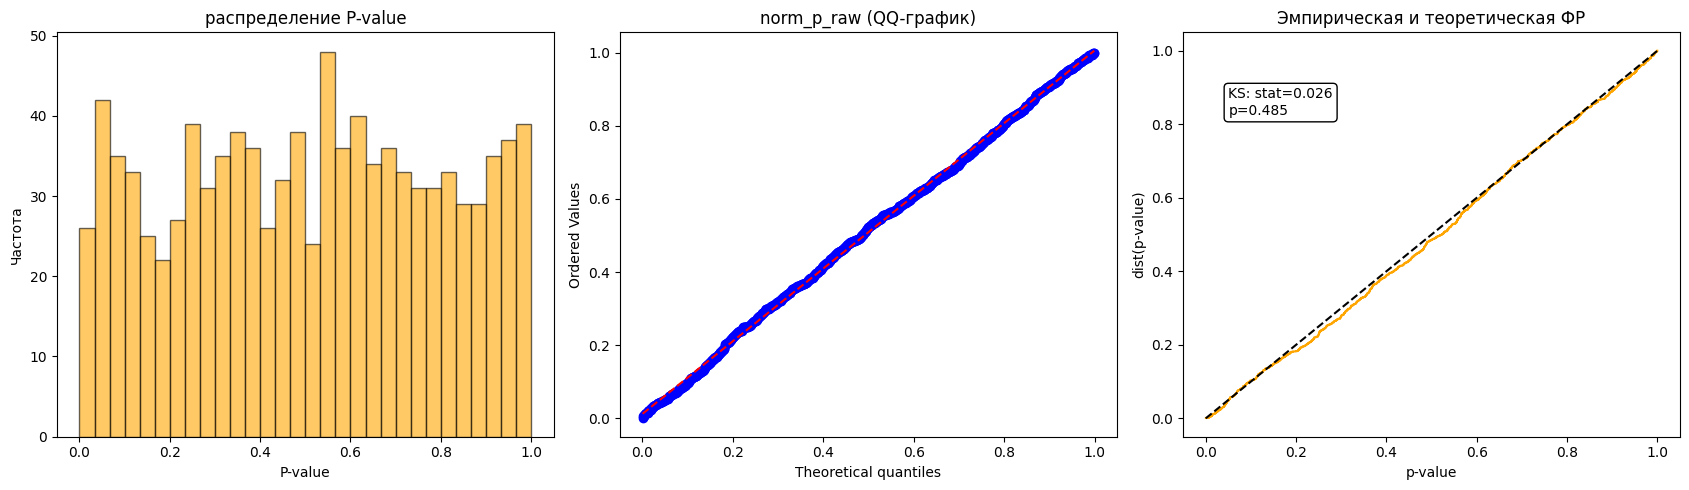

In [317]:
plot_comparison_with_uniform(pval_raw, "norm_p_raw")

Ошибка I рода: 0.052,
CI для oшибки I рода: [0.0382, 0.0658]
()
Статистика Колмогорова-Смирнова: 0.027, pvalue для сравнения ЭФР с равномерным: 0.461
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


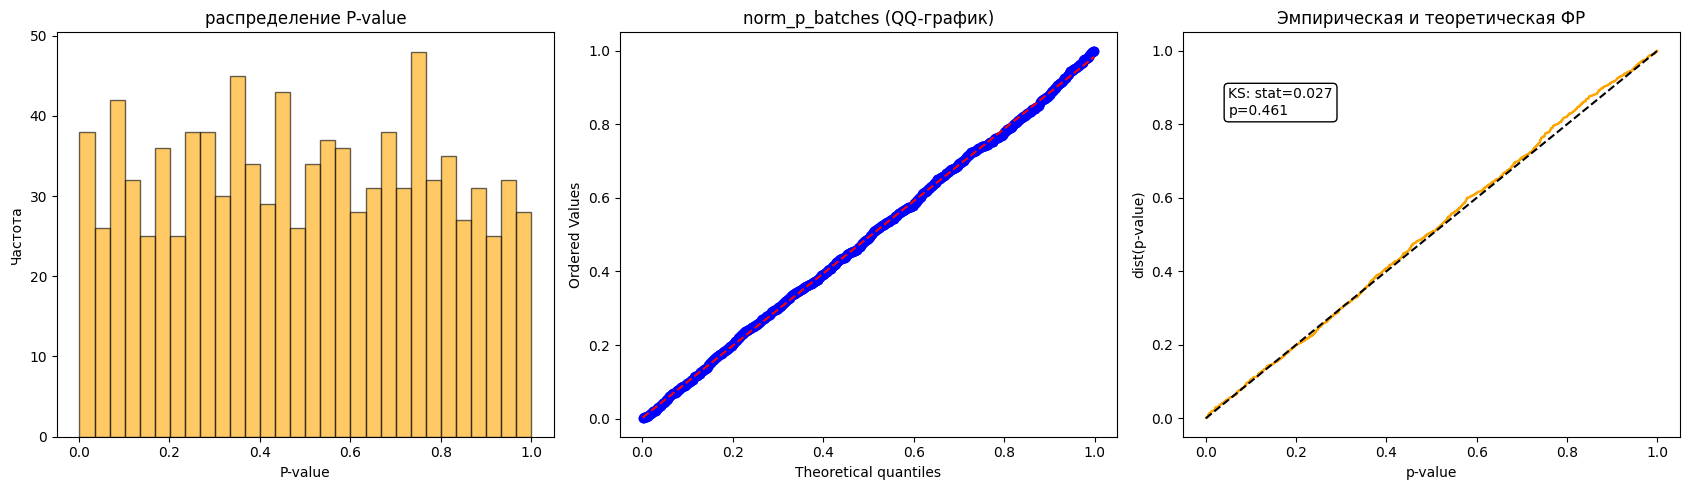

In [318]:
plot_comparison_with_uniform(pval_batches, "norm_p_batches")

Ошибка I рода: 0.043,
CI для oшибки I рода: [0.0304, 0.0556]
()
Статистика Колмогорова-Смирнова: 0.0267, pvalue для сравнения ЭФР с равномерным: 0.473
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


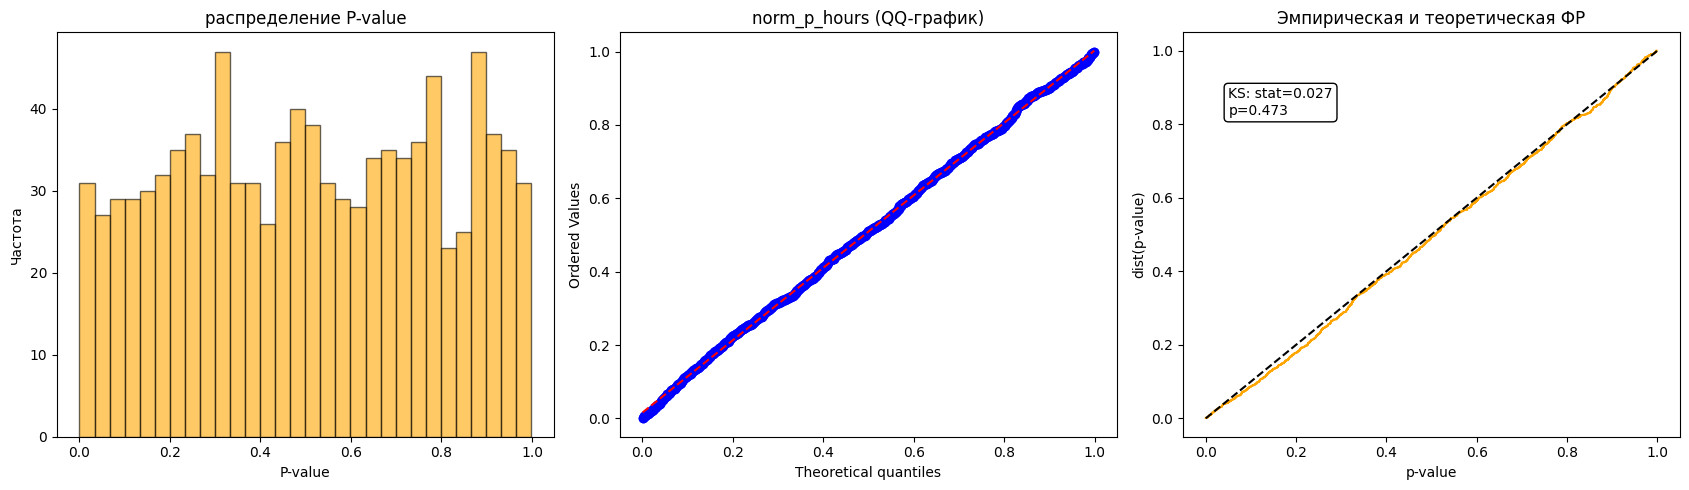

In [319]:
plot_comparison_with_uniform(pvalue_hour, "norm_p_hours")

Видим, что все агрегации корректы. При прочих равных, веберм батчи.

### 2.5 A/B тест

теперь у нас есть метод агрегации и стат. тест, у которого проверили валидность. 

остально только проверить, какой ответ дадут нам данные

In [320]:
n_batches = 2000

batches_control = np.array_split(vec_control, n_batches)
batches_treatment = np.array_split(vec_treatment, n_batches)

avg_batches_control = pd.Series([batch.mean() for batch in batches_control])
avg_batches_treatment = pd.Series([batch.mean() for batch in batches_treatment])

z_stat, p_value = student_ttest(avg_batches_control, avg_batches_treatment)
z_stat, p_value

(np.float64(1.2268793634871291), np.float64(0.2199401797798036))

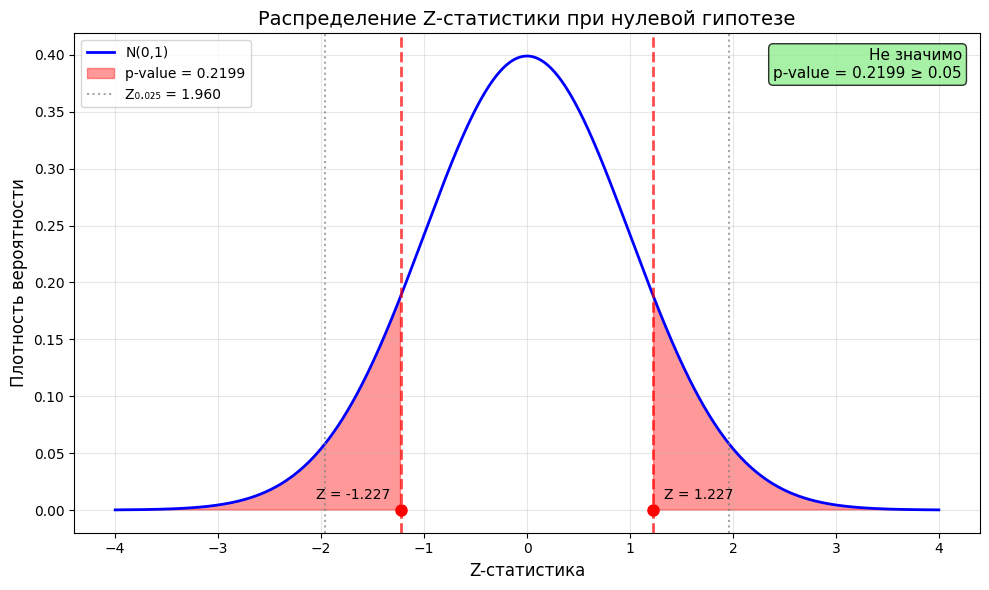

In [321]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


fig, ax = plt.subplots(figsize=(10, 6))
z_for_plot = np.linspace(-4, 4, 1000)

ax.plot(z_for_plot, stats.norm.pdf(z_for_plot, 0, 1), 'b-', linewidth=2, label='N(0,1)')

ax.fill_between(z_for_plot, stats.norm.pdf(z_for_plot, 0, 1), 0,
                where=(np.abs(z_for_plot) >= z_stat),
                color='red', alpha=0.4, label=f'p-value = {p_value:.4f}')

ax.axvline(x=z_stat, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(x=-z_stat, color='red', linestyle='--', linewidth=2, alpha=0.7)

ax.plot(z_stat, 0, 'ro', markersize=8)
ax.plot(-z_stat, 0, 'ro', markersize=8)

ax.text(z_stat + 0.1, 0.01, f'Z = {z_stat:.3f}', fontsize=10, ha='left')
ax.text(-z_stat - 0.1, 0.01, f'Z = {-z_stat:.3f}', fontsize=10, ha='right')

z_critical = stats.norm.ppf(0.975)
ax.axvline(x=z_critical, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, 
           label=f'Z₀.₀₂₅ = {z_critical:.3f}')
ax.axvline(x=-z_critical, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Z-статистика', fontsize=12)
ax.set_ylabel('Плотность вероятности', fontsize=12)
ax.set_title('Распределение Z-статистики при нулевой гипотезе', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

if p_value < 0.05:
    result_text = f'Статистически значимо\np-value = {p_value:.4f} < 0.05'
    box_color = 'lightcoral'
else:
    result_text = f'Не значимо\np-value = {p_value:.4f} ≥ 0.05'
    box_color = 'lightgreen'

ax.text(0.98, 0.97, result_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.8))

plt.tight_layout()
plt.show()

Получаем, что **стат. значимости нет**

## 2.6 z-тест

Также сделаем z-тест на пропоции.

In [323]:
p_total = data['converted'].sum()/data['converted'].count()
p_total

np.float64(0.11965919355605512)

In [324]:
SE = (p_total*(1-p_total)*(1/n1+1/n2))**0.5
SE

np.float64(0.0011961951420265313)

In [325]:
Z = (p1-p2)/SE
Z

np.float64(1.2369217547321678)

In [326]:
norm.cdf(Z)

np.float64(0.8919419336512124)

Z = 0,9049  это то, что внутри (односторонняя?)

p-value = 1-0,9049 = 0,0951 > 0.05

статистически значимого различия нет
H0 выиграла